# InstABoost: Effect of Bias Strength on Airline RuleArena Performance

This notebook compares the first 20 samples of `openai/gpt-oss-120b` on the airline domain (`comp_0`)
across the baseline (no boosting) and 6 uniform-rules bias values (0.1, 0.3, 0.5, 0.7, 1.0, 1.5).

**Metrics compared:**
- **Accuracy**: fraction of samples where `predicted_answer == ground_truth_answer`
- **Generation finished ratio**: fraction of samples where the model completed generation before hitting the token limit
- **Average output length (tokens)**: mean number of output tokens across samples
- **Wall time (seconds)**: total elapsed (clock) time to process all 20 samples

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

In [2]:
# --- Paths ---
BASE_DIR = "/shared_data0/vitoriag/multi-rules/results"
BASELINE_DIR = os.path.join(BASE_DIR, "rulearena/openai_gpt-oss-120b/airline/comp_0/none")
BOOSTED_ROOT = os.path.join(BASE_DIR, "val/rulearena/openai_gpt-oss-120b/airline/comp_0")

BIAS_VALUES = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
N_SAMPLES = 20


def load_samples(directory, n=N_SAMPLES):
    """Load the first n sample JSON files from a results directory."""
    samples = []
    for i in range(n):
        path = os.path.join(directory, f"{i}.json")
        with open(path) as f:
            samples.append(json.load(f))
    return samples


def compute_metrics(samples):
    """Compute summary metrics from a list of sample dicts."""
    n = len(samples)
    return {
        "accuracy": sum(s["is_correct"] for s in samples) / n,
        "generation_finished_ratio": sum(s["generation_finished"] for s in samples) / n,
        "avg_output_length_tokens": np.mean([s["output_length_tokens"] for s in samples]),
        "wall_time_seconds": sum(s["sample_time_seconds"] for s in samples),
    }


# --- Load all configs ---
results = {}
for bias in BIAS_VALUES:
    if bias == 0.0:
        directory = BASELINE_DIR
    else:
        bias_str = f"{bias:.1f}" if bias == int(bias) else str(bias)
        directory = os.path.join(BOOSTED_ROOT, f"uniform_rules_bias{bias_str}")
    samples = load_samples(directory)
    results[bias] = compute_metrics(samples)

df = pd.DataFrame(results).T
df.index.name = "bias"
df

,accuracy,generation_finished_ratio,avg_output_length_tokens,wall_time_seconds
bias,,,,
0.0,0.40,1.0,2224.15,4084.79
0.1,0.45,1.0,2376.15,4408.52
0.3,0.45,1.0,2241.30,4131.09
0.5,0.45,1.0,2338.95,4341.02
0.7,0.40,1.0,2241.35,4227.54
1.0,0.40,1.0,2345.50,4338.91
1.5,0.45,1.0,2360.40,4436.44
2.0,0.50,1.0,2477.85,4706.61
3.0,0.25,1.0,2588.00,4875.35


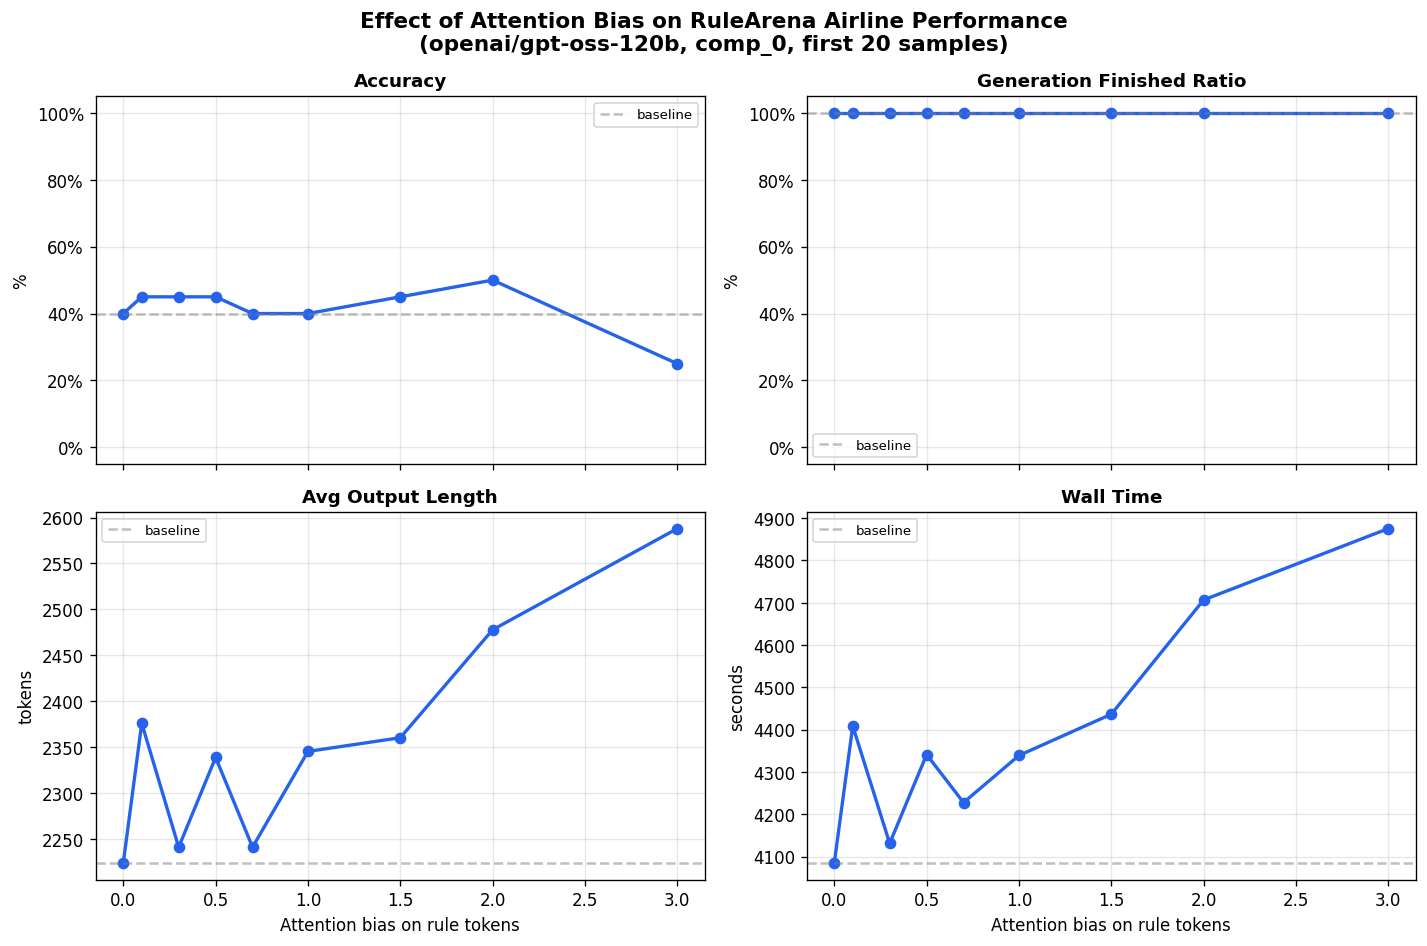

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
fig.suptitle(
    "Effect of Attention Bias on RuleArena Airline Performance\n"
    "(openai/gpt-oss-120b, comp_0, first 20 samples)",
    fontsize=13,
    fontweight="bold",
)

metrics = [
    ("accuracy", "Accuracy", "%"),
    ("generation_finished_ratio", "Generation Finished Ratio", "%"),
    ("avg_output_length_tokens", "Avg Output Length", "tokens"),
    ("wall_time_seconds", "Wall Time", "seconds"),
]

for ax, (col, title, unit) in zip(axes.flat, metrics):
    values = df[col].values
    biases = df.index.values

    # Plot
    ax.plot(biases, values, "o-", color="#2563eb", linewidth=2, markersize=6)

    # Highlight baseline
    ax.axhline(values[0], color="gray", linestyle="--", alpha=0.5, label="baseline")

    # Labels
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(unit)
    if ax in axes[1]:
        ax.set_xlabel("Attention bias on rule tokens")

    # Format y-axis as percentage where appropriate
    if unit == "%":
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
        ax.set_ylim(-0.05, 1.05)

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Per-sample correctness heatmap

Each row is a bias value, each column is a sample index. Green = correct, red = wrong, gray = generation did not finish.

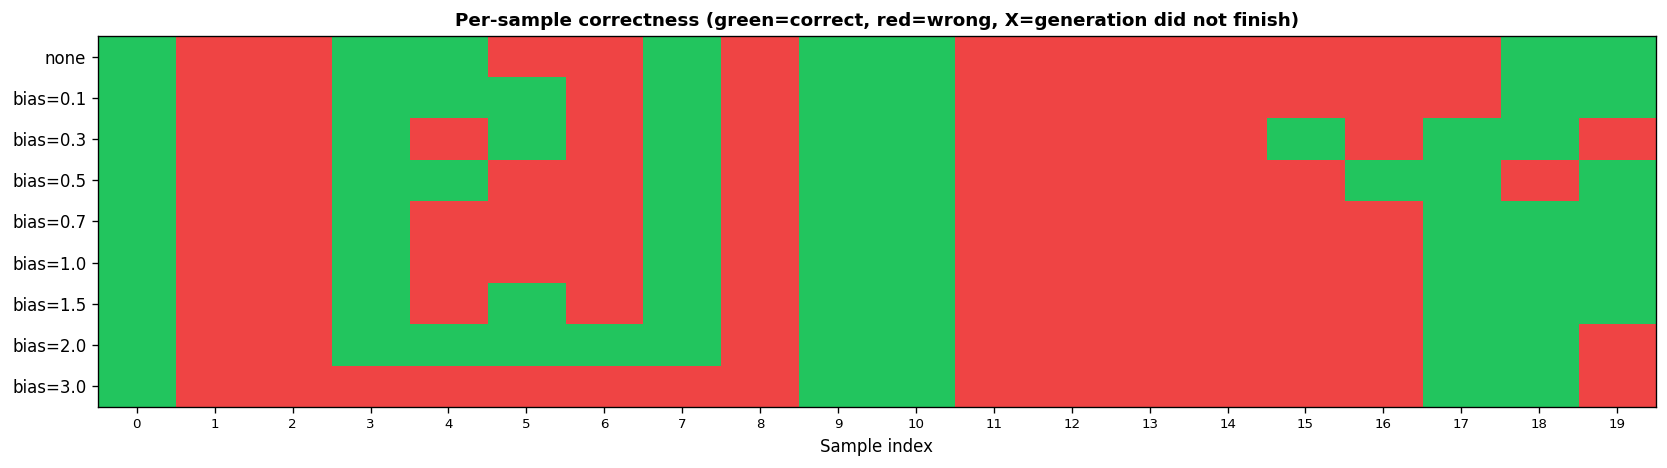

In [4]:
# Build per-sample matrix
correctness = np.zeros((len(BIAS_VALUES), N_SAMPLES))
finished = np.zeros((len(BIAS_VALUES), N_SAMPLES), dtype=bool)

for i, bias in enumerate(BIAS_VALUES):
    if bias == 0.0:
        directory = BASELINE_DIR
    else:
        bias_str = f"{bias:.1f}" if bias == int(bias) else str(bias)
        directory = os.path.join(BOOSTED_ROOT, f"uniform_rules_bias{bias_str}")
    for j in range(N_SAMPLES):
        with open(os.path.join(directory, f"{j}.json")) as f:
            s = json.load(f)
        correctness[i, j] = 1 if s["is_correct"] else 0
        finished[i, j] = s["generation_finished"]

# Color: correct=green(1), wrong=red(0), unfinished shown via hatching
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(14, 4))
cmap = ListedColormap(["#ef4444", "#22c55e"])  # red, green
im = ax.imshow(correctness, cmap=cmap, aspect="auto", vmin=0, vmax=1)

# Mark unfinished generations with an X
for i in range(len(BIAS_VALUES)):
    for j in range(N_SAMPLES):
        if not finished[i, j]:
            ax.text(j, i, "X", ha="center", va="center", fontsize=8,
                    color="white", fontweight="bold")

ax.set_yticks(range(len(BIAS_VALUES)))
ax.set_yticklabels([f"bias={b}" if b > 0 else "none" for b in BIAS_VALUES])
ax.set_xticks(range(N_SAMPLES))
ax.set_xticklabels(range(N_SAMPLES), fontsize=8)
ax.set_xlabel("Sample index")
ax.set_title(
    "Per-sample correctness (green=correct, red=wrong, X=generation did not finish)",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
plt.show()

### Summary table with deltas from baseline

In [5]:
# Format a summary table with deltas from baseline
baseline = df.loc[0.0]
summary = df.copy()
summary["accuracy_delta"] = summary["accuracy"] - baseline["accuracy"]
summary["gen_finished_delta"] = summary["generation_finished_ratio"] - baseline["generation_finished_ratio"]
summary["tokens_delta"] = summary["avg_output_length_tokens"] - baseline["avg_output_length_tokens"]
summary["wall_time_delta"] = summary["wall_time_seconds"] - baseline["wall_time_seconds"]

display_cols = [
    "accuracy", "accuracy_delta",
    "generation_finished_ratio", "gen_finished_delta",
    "avg_output_length_tokens", "tokens_delta",
    "wall_time_seconds", "wall_time_delta",
]

styled = (
    summary[display_cols]
    .style
    .format({
        "accuracy": "{:.0%}",
        "accuracy_delta": "{:+.0%}",
        "generation_finished_ratio": "{:.0%}",
        "gen_finished_delta": "{:+.0%}",
        "avg_output_length_tokens": "{:,.0f}",
        "tokens_delta": "{:+,.0f}",
        "wall_time_seconds": "{:,.0f}",
        "wall_time_delta": "{:+,.0f}",
    })
    .background_gradient(
        subset=["accuracy_delta"], cmap="RdYlGn", vmin=-0.3, vmax=0.3
    )
    .background_gradient(
        subset=["gen_finished_delta"], cmap="RdYlGn", vmin=-0.5, vmax=0.5
    )
)
styled

,accuracy,accuracy_delta,generation_finished_ratio,gen_finished_delta,avg_output_length_tokens,tokens_delta,wall_time_seconds,wall_time_delta
bias,,,,,,,,
0.000000,40%,+0%,100%,+0%,"2,224",+0,"4,085",+0
0.100000,45%,+5%,100%,+0%,"2,376",+152,"4,409",+324
0.300000,45%,+5%,100%,+0%,"2,241",+17,"4,131",+46
0.500000,45%,+5%,100%,+0%,"2,339",+115,"4,341",+256
0.700000,40%,+0%,100%,+0%,"2,241",+17,"4,228",+143
1.000000,40%,+0%,100%,+0%,"2,346",+121,"4,339",+254
1.500000,45%,+5%,100%,+0%,"2,360",+136,"4,436",+352
2.000000,50%,+10%,100%,+0%,"2,478",+254,"4,707",+622
3.000000,25%,-15%,100%,+0%,"2,588",+364,"4,875",+791
